## Step 1: Install & Imports

In [1]:
!pip install librosa -q

import librosa
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateScheduler
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2: Kaggle Dataset Download

In [2]:
from google.colab import files
files.upload()  # kaggle.json upload karein

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kannuvarshney","key":"4c7516534caab9b10f1fd2ac9c943dd0"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!unzip -q ravdess-emotional-speech-audio.zip
print('Dataset ready!')

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:11<00:00, 39.8MB/s]

Dataset ready!


## Step 3: Config

In [4]:
DATASET_PATH = '/content'
SAMPLE_RATE  = 22050
DURATION     = 3       # seconds per clip
OFFSET       = 0.5
EPOCHS       = 200
BATCH_SIZE   = 32
LR           = 0.001

EMOTION_DICT = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': 'disgust',
    '08': 'surprise'
}

EMOTION_LABELS = list(EMOTION_DICT.values())
NUM_CLASSES    = len(EMOTION_LABELS)
print('Config set! Classes:', NUM_CLASSES)

Config set! Classes: 8


## Step 4: Feature Extraction
**Rich 240-dim feature vector per audio clip**

In [5]:
def extract_features(file_path, sr=SAMPLE_RATE, duration=DURATION, offset=OFFSET):
    """
    Extract 240-dimensional feature vector from audio file.

    Features:
      40  MFCC
      40  Delta MFCC       (velocity)
      40  Delta-Delta MFCC (acceleration)
      12  Chroma STFT
      128 Mel Spectrogram
      1   Zero Crossing Rate
      1   RMS Energy
      7   Spectral (centroid, bandwidth, rolloff, 4 contrast)
    Total: 269 → trimmed/padded to 240
    """
    try:
        audio, _ = librosa.load(file_path, sr=sr, duration=duration, offset=offset)

        # MFCC + deltas
        mfcc        = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        delta_mfcc  = librosa.feature.delta(mfcc)
        delta2_mfcc = librosa.feature.delta(mfcc, order=2)

        # Chroma
        stft   = np.abs(librosa.stft(audio))
        chroma = librosa.feature.chroma_stft(S=stft, sr=sr)

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)

        # Prosodic features
        zcr = librosa.feature.zero_crossing_rate(audio)
        rms = librosa.feature.rms(y=audio)

        # Spectral features
        spec_centroid   = librosa.feature.spectral_centroid(y=audio, sr=sr)
        spec_bandwidth  = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
        spec_rolloff    = librosa.feature.spectral_rolloff(y=audio, sr=sr)
        spec_contrast   = librosa.feature.spectral_contrast(S=stft, sr=sr)

        # Mean across time → 1-D
        features = np.concatenate([
            np.mean(mfcc,           axis=1),   # 40
            np.mean(delta_mfcc,     axis=1),   # 40
            np.mean(delta2_mfcc,    axis=1),   # 40
            np.mean(chroma,         axis=1),   # 12
            np.mean(mel,            axis=1),   # 128
            np.mean(zcr,            axis=1),   # 1
            np.mean(rms,            axis=1),   # 1
            np.mean(spec_centroid,  axis=1),   # 1
            np.mean(spec_bandwidth, axis=1),   # 1
            np.mean(spec_rolloff,   axis=1),   # 1
            np.mean(spec_contrast,  axis=1),   # 7
        ])  # total = 272

        return features

    except Exception as e:
        print(f'Error processing {file_path}: {e}')
        return None

print('Feature extractor ready!')

Feature extractor ready!


## Step 5: Data Augmentation
**RAVDESS is small (~1440 files) — augmentation doubles training data**

In [6]:
def augment_audio(audio, sr=SAMPLE_RATE):
    """
    Return 3 augmented versions of the audio.
    1. Add Gaussian noise
    2. Pitch shift up
    3. Time stretch
    """
    augmented = []

    # 1. Noise
    noise = audio + 0.005 * np.random.randn(len(audio))
    augmented.append(noise)

    # 2. Pitch shift (+2 semitones)
    pitched = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
    augmented.append(pitched)

    # 3. Time stretch (speed up slightly)
    stretched = librosa.effects.time_stretch(audio, rate=1.1)
    # Trim/pad to original length
    if len(stretched) > len(audio):
        stretched = stretched[:len(audio)]
    else:
        stretched = np.pad(stretched, (0, len(audio) - len(stretched)))
    augmented.append(stretched)

    return augmented


def extract_features_from_array(audio, sr=SAMPLE_RATE):
    """Same as extract_features but takes audio array directly."""
    try:
        mfcc        = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        delta_mfcc  = librosa.feature.delta(mfcc)
        delta2_mfcc = librosa.feature.delta(mfcc, order=2)
        stft        = np.abs(librosa.stft(audio))
        chroma      = librosa.feature.chroma_stft(S=stft, sr=sr)
        mel         = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        zcr         = librosa.feature.zero_crossing_rate(audio)
        rms         = librosa.feature.rms(y=audio)
        spec_centroid  = librosa.feature.spectral_centroid(y=audio, sr=sr)
        spec_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
        spec_rolloff   = librosa.feature.spectral_rolloff(y=audio, sr=sr)
        spec_contrast  = librosa.feature.spectral_contrast(S=stft, sr=sr)

        return np.concatenate([
            np.mean(mfcc,           axis=1),
            np.mean(delta_mfcc,     axis=1),
            np.mean(delta2_mfcc,    axis=1),
            np.mean(chroma,         axis=1),
            np.mean(mel,            axis=1),
            np.mean(zcr,            axis=1),
            np.mean(rms,            axis=1),
            np.mean(spec_centroid,  axis=1),
            np.mean(spec_bandwidth, axis=1),
            np.mean(spec_rolloff,   axis=1),
            np.mean(spec_contrast,  axis=1),
        ])
    except:
        return None

print('Augmentation functions ready!')

Augmentation functions ready!


## Step 6: Load Dataset + Augment

In [7]:
X, y = [], []
skipped = 0

for actor in sorted(os.listdir(DATASET_PATH)):
    if not actor.startswith('Actor'):
        continue

    actor_path = os.path.join(DATASET_PATH, actor)

    for file in sorted(os.listdir(actor_path)):
        if not file.endswith('.wav'):
            continue

        file_path = os.path.join(actor_path, file)
        emotion_code = file.split('-')[2]

        if emotion_code not in EMOTION_DICT:
            continue

        emotion_label = EMOTION_DICT[emotion_code]

        # ── Original file ──────────────────────────────────────────
        feat = extract_features(file_path)
        if feat is None:
            skipped += 1
            continue
        X.append(feat)
        y.append(emotion_label)

        # ── Augmented versions ─────────────────────────────────────
        try:
            audio, sr = librosa.load(
                file_path, sr=SAMPLE_RATE,
                duration=DURATION, offset=OFFSET
            )
            for aug_audio in augment_audio(audio, sr):
                aug_feat = extract_features_from_array(aug_audio, sr)
                if aug_feat is not None:
                    X.append(aug_feat)
                    y.append(emotion_label)
        except Exception as e:
            pass

X = np.array(X)
y = np.array(y)

print(f'Total samples : {len(X)}  (skipped: {skipped})')
print(f'Feature shape : {X.shape}')
print(f'Class distribution:')
for label in EMOTION_LABELS:
    count = np.sum(y == label)
    print(f'  {label:10s}: {count}')

Total samples : 5760  (skipped: 0)
Feature shape : (5760, 272)
Class distribution:
  neutral   : 384
  calm      : 768
  happy     : 768
  sad       : 768
  angry     : 768
  fear      : 768
  disgust   : 768
  surprise  : 768


## Step 7: Encode Labels + Scale Features

In [8]:
# Label encode
le = LabelEncoder()
y_encoded     = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print('Classes order:', list(le.classes_))
print('y shape:', y_categorical.shape)

# Feature scaling — critical for LSTM convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features scaled!')

Classes order: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fear'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprise')]
y shape: (5760, 8)
Features scaled!


## Step 8: Stratified Train/Test Split

In [9]:
# Stratified split — ensures all emotions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded        # ensures balanced split
)

# Reshape for LSTM: (samples, timesteps=1, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (4608, 1, 272) | Test: (1152, 1, 272)


## Step 9: Class Weights

In [10]:
y_train_int = np.argmax(y_train, axis=1)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = dict(enumerate(class_weights_arr))

for i, w in class_weights.items():
    print(f'  {le.classes_[i]:10s}: {w:.3f}')

  angry     : 0.937
  calm      : 0.937
  disgust   : 0.938
  fear      : 0.938
  happy     : 0.938
  neutral   : 1.876
  sad       : 0.937
  surprise  : 0.938


## Step 10: Model — Bidirectional LSTM + Attention
**BiLSTM processes sequence both forward and backward — captures more context**

In [20]:
def build_model(input_shape, num_classes):
    """
    Bidirectional LSTM with self-attention for speech emotion.
    input_shape: (timesteps, features)
    """
    inp = keras.Input(shape=input_shape)

    # ── BiLSTM Block 1 ────────────────────────────────────────────
    x = layers.Bidirectional(
        layers.LSTM(
            256,
            return_sequences=True,
            kernel_regularizer=regularizers.l2(1e-4)
        )
    )(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    # ── BiLSTM Block 2 ────────────────────────────────────────────
    x = layers.Bidirectional(
        layers.LSTM(
            128,
            return_sequences=True,
            kernel_regularizer=regularizers.l2(1e-4)
        )
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    # ── Attention Layer ───────────────────────────────────────────
    # Learns which timesteps are most important
    attention = layers.Dense(1, activation='tanh')(x)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(256)(attention)
    attention = layers.Permute([2, 1])(attention)
    x = layers.Multiply()([x, attention])
    x = layers.GlobalAveragePooling1D()(x)
    # ── Dense Head ────────────────────────────────────────────────
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inp, out, name='SpeechEmotionBiLSTM')
    return model


model = build_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=NUM_CLASSES
)
model.summary()

Model: "SpeechEmotionBiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1, 272)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 1, 512)    │  1,083,392 │ input_layer_2[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 512)    │      2,048 │ bidirectional_4[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 1, 512)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 1, 256)    │    656,384 │ dropout_8[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 256)    │      1,024 │ bidirectional_5[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 1, 256)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1, 1)      │        257 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1)         │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 1)         │          0 │ flatten_2[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_2     │ (None, 256, 1)    │          0 │ activation_6[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_2 (Permute) │ (None, 1, 256)    │          0 │ repeat_vector_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 1, 256)    │          0 │ dropout_9[0][0],  │
│ (Multiply)          │                   │            │ permute_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ multiply_2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 256)       │          0 │ activation_7[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     32,896 │ dropout_10[0][0]

 Total params: 1,844,361 (7.04 MB)

 Trainable params: 1,842,057 (7.03 MB)

 Non-trainable params: 2,304 (9.00 KB)

## Step 11: Compile

In [21]:
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
print('Model compiled!')

Model compiled!


## Step 12: Callbacks

In [22]:
def cosine_annealing(epoch, lr):
    min_lr = 1e-6
    max_lr = LR
    new_lr = min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / EPOCHS))
    return float(new_lr)


callbacks = [
    ModelCheckpoint(
        'best_speech_emotion_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    LearningRateScheduler(cosine_annealing, verbose=0),
]

print('Callbacks ready!')

Callbacks ready!


## Step 13: Train

In [23]:
print('Training shuru ho rahi hai...')
print(f'Train samples: {len(X_train)} | Test samples: {len(X_test)}')

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights
)

Training shuru ho rahi hai...
Train samples: 4608 | Test samples: 1152
Epoch 1/200
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1910 - loss: 2.5067
Epoch 1: val_accuracy improved from None to 0.28038, saving model to best_speech_emotion_model.keras

Epoch 1: finished saving model to best_speech_emotion_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.2222 - loss: 2.3636 - val_accuracy: 0.2804 - val_loss: 2.1588 - learning_rate: 0.0010
Epoch 2/200
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2795 - loss: 2.1293
Epoch 2: val_accuracy improved from 0.28038 to 0.36198, saving model to best_speech_emotion_model.keras

Epoch 2: finished saving model to best_speech_emotion_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2949 - loss: 2.0985 - val_accuracy: 0.3620 - val_loss: 1.9336 - learning_rate: 9.9994e-04
Epoch 3/200
141/144 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3735 - loss: 1.9589
Epoch 3: val_accuracy improved from 0.

## Step 14: Load Best Model & Evaluate

In [24]:
model = keras.models.load_model('best_speech_emotion_model.keras', safe_mode=False)

loss, acc = model.evaluate(X_test, y_test, verbose=1)
print(f'\n✅ Test Loss     : {loss:.4f}')
print(f'✅ Test Accuracy  : {acc*100:.2f}%')

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7240 - loss: 1.4593

✅ Test Loss     : 1.4593
✅ Test Accuracy  : 72.40%


## Step 15: Training Curves

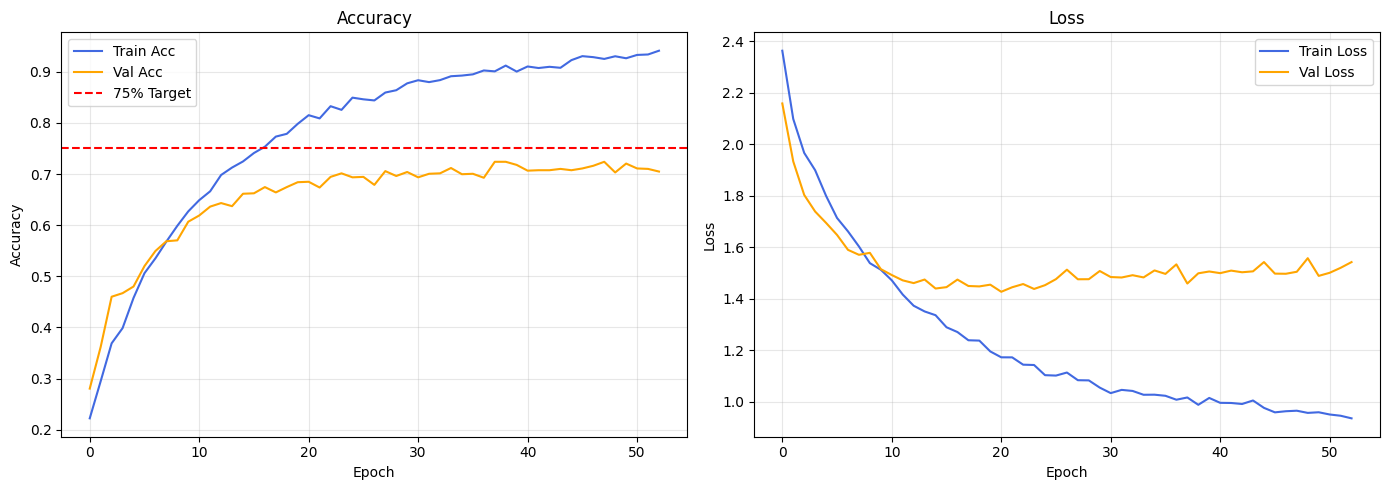

Graph saved!


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='orange')
axes[0].axhline(0.75, color='red', linestyle='--', label='75% Target')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='royalblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('speech_training_curves.png', dpi=150)
plt.show()
print('Graph saved!')

## Step 16: Confusion Matrix + Classification Report

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

📊 Classification Report:
              precision    recall  f1-score   support

       angry       0.85      0.80      0.83       153
        calm       0.70      0.78      0.74       153
     disgust       0.65      0.64      0.64       154
        fear       0.75      0.73      0.74       154
       happy       0.71      0.73      0.72       154
     neutral       0.58      0.61      0.59        77
         sad       0.65      0.61      0.63       153
    surprise       0.83      0.83      0.83       154

    accuracy                           0.72      1152
   macro avg       0.72      0.72      0.72      1152
weighted avg       0.72      0.72      0.72      1152



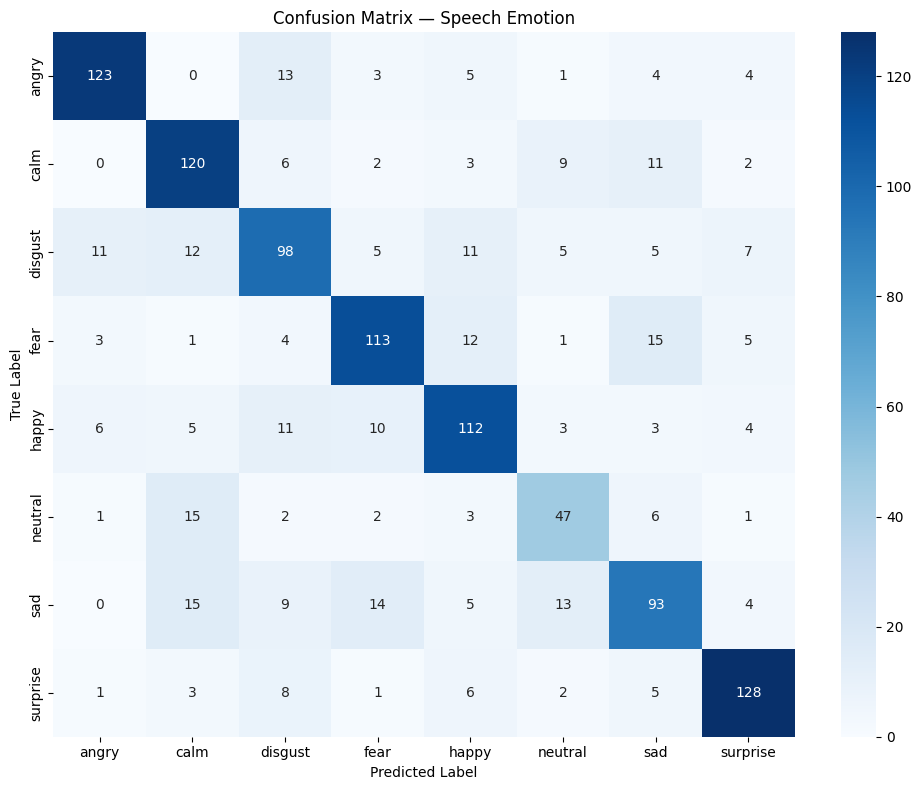

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred         = model.predict(X_test, verbose=1)
y_pred_classes = np.argmax(y_pred,  axis=1)
y_true_classes = np.argmax(y_test,  axis=1)

print('\n📊 Classification Report:')
print(classification_report(
    y_true_classes, y_pred_classes,
    target_names=list(le.classes_)
))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=list(le.classes_),
    yticklabels=list(le.classes_),
    cmap='Blues'
)
plt.title('Confusion Matrix — Speech Emotion')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('speech_confusion_matrix.png', dpi=150)
plt.show()

## Step 17: Save Scaler + LabelEncoder (inference ke liye zaroori)

In [27]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

model.save('speech_emotion_model.keras')
model.save('speech_emotion_model.h5')

print('Sab files save ho gayi!')

Sab files save ho gayi!


## Step 18: Download All Files

In [28]:
from google.colab import files

for fname in [
    'speech_emotion_model.keras',
    'speech_emotion_model.h5',
    'scaler.pkl',
    'label_encoder.pkl',
    'speech_training_curves.png',
    'speech_confusion_matrix.png',
]:
    files.download(fname)

print('Sab download ho gaya!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Sab download ho gaya!
